# 04. AutoIntent: Full Train

Сравнение моделей на полном обучающем наборе (15 250 примеров).

**Референс:** AutoIntent Table 3 (CLINC150 full train)
- F1 OOS: 0.768
- In-Domain Acc: 0.961

## Содержание
1. Setup
2. Загрузка результатов
3. Сравнение с результатами статьи
4. Визуализация
5. Scaling Curve: few-shot → full train
6. Выводы

## 1. Setup

In [5]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"
RUNS = TASK_DIR / "runs"

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS}")
print(f"Runs dir: {RUNS}")

import os
print(f"\nOMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS', 'not set')}")

Project root: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails
Results dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results
Runs dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/runs

OMP_NUM_THREADS=1


## 2. Загрузка результатов

In [6]:
# Load full train results
results_full = json.loads((RESULTS / "metrics.json").read_text())
df_full = pd.DataFrame(results_full)

# Filter full train results
df_full_train = df_full[df_full["mode"] == "full"].copy()
df_full_train = df_full_train.sort_values("f1_oos", ascending=False)

print(f"Full train results: {len(df_full_train)}")
if len(df_full_train) > 0:
    print(f"Models: {df_full_train['model_name'].tolist()}")

Full train results: 9
Models: ['autointent_classic-light', 'cosine_e5large_threshold', 'cosine_minilm_threshold', 'cosine_bert_argmax', 'cosine_minilm_argmax', 'tfidf_threshold', 'cosine_bert_threshold', 'tfidf_argmax', 'cosine_e5large_argmax']


## 3. Сравнение с результатами статьи

In [7]:
# Comparison table with reference
if len(df_full_train) > 0:
    # Select columns
    cols = ["model_name", "oos_recall", "in_domain_acc", "f1_oos", "auroc", "latency_ms"]
    table = df_full_train[cols].copy()
    table.columns = ["Model", "OOS Recall", "In-Domain Acc", "F1 OOS", "AUROC", "Latency (ms)"]
    
    # Add reference row (Table 3)
    ref_row = pd.DataFrame([{
        "Model": "AutoIntent Table 3 (ref)",
        "OOS Recall": None,
        "In-Domain Acc": 0.9613,
        "F1 OOS": 0.7679,
        "AUROC": None,
        "Latency (ms)": None,
    }])
    table = pd.concat([table, ref_row], ignore_index=True)
    
    # Format
    for col in ["OOS Recall", "In-Domain Acc", "F1 OOS", "AUROC"]:
        table[col] = table[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
    table["Latency (ms)"] = table["Latency (ms)"].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
    
    print("Full Train Results Comparison")
    print("=" * 70)
    display(table)
else:
    print("[Результаты full train ещё не получены]")

Full Train Results Comparison


,Model,OOS Recall,In-Domain Acc,F1 OOS,AUROC,Latency (ms)
0,autointent_classic-light,0.8350,0.9400,0.8413,0.9737,0.19
1,cosine_e5large_threshold,0.5950,0.9077,0.7195,0.9611,19.24
2,cosine_minilm_threshold,0.4940,0.8748,0.6420,0.9625,7.12
3,cosine_bert_argmax,0.8460,0.6959,0.6015,0.8976,14.84
4,cosine_minilm_argmax,0.9970,0.4598,0.4559,0.9625,7.31
5,tfidf_threshold,0.2770,0.8842,0.4165,0.8981,3.14
6,cosine_bert_threshold,0.2690,0.8250,0.3968,0.8976,14.76
7,tfidf_argmax,0.1200,0.8906,0.2130,0.8981,1.54
8,cosine_e5large_argmax,0.1110,0.9146,0.1996,0.9611,19.79
9,AutoIntent Table 3 (ref),—,0.9613,0.7679,—,—


## 4. Визуализация

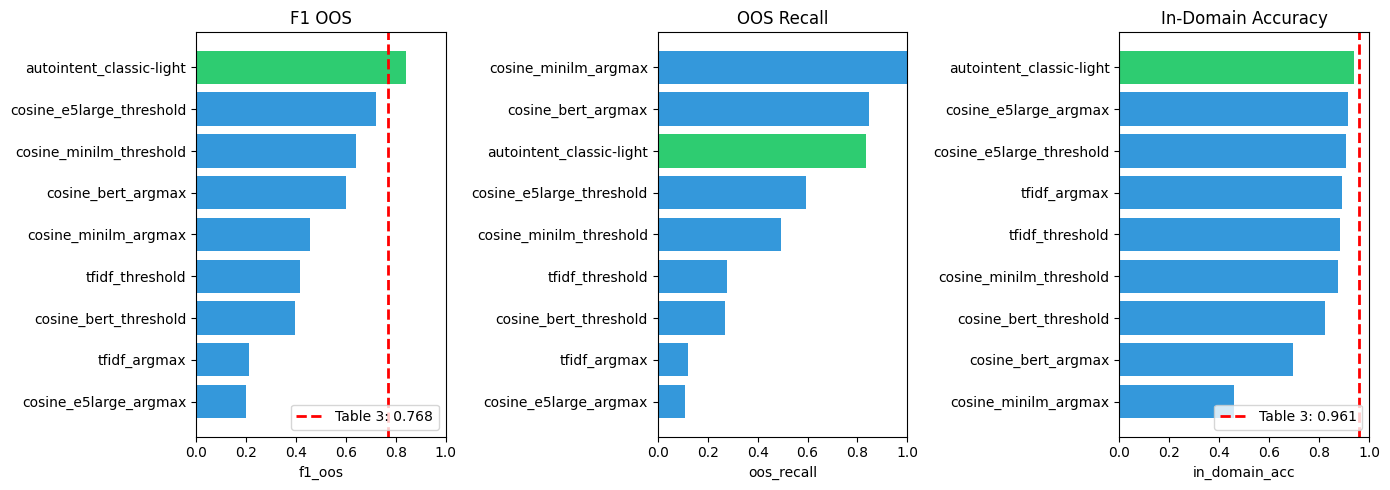

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/comparison_full_train.png


In [8]:
# Visualization: Full train comparison
if len(df_full_train) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    
    metrics_to_plot = [
        ("f1_oos", "F1 OOS", 0.7679),  # with Table 3 reference
        ("oos_recall", "OOS Recall", None),
        ("in_domain_acc", "In-Domain Accuracy", 0.9613),  # with Table 3 reference
    ]
    
    for ax, (metric, title, ref_val) in zip(axes, metrics_to_plot):
        data = df_full_train.sort_values(metric, ascending=True)
        colors = ['#2ecc71' if 'autointent' in m.lower() else '#3498db' 
                  for m in data['model_name']]
        
        bars = ax.barh(data['model_name'], data[metric], color=colors)
        
        # Add reference line
        if ref_val is not None:
            ax.axvline(x=ref_val, color='red', linestyle='--', linewidth=2, 
                       label=f'Table 3: {ref_val:.3f}')
            ax.legend(loc='lower right')
        
        ax.set_xlabel(metric)
        ax.set_title(title)
        ax.set_xlim(0, 1)
    
    plt.tight_layout()
    plt.savefig(RESULTS / "comparison_full_train.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'comparison_full_train.png'}")
else:
    print("[Визуализация недоступна]")

## 5. Scaling Curve: few-shot → full train

Как меняется качество AutoIntent при увеличении объёма обучающих данных
от 10-shot до полного обучающего набора (15 250 примеров).

In [9]:
# 5.1 Scaling Curve: few-shot → full train
results_scaling = json.loads((RESULTS / "metrics.json").read_text())
df_scaling = pd.DataFrame(results_scaling)

# Filter AutoIntent results only
df_ai = df_scaling[df_scaling["model_name"] == "autointent_classic-light"].copy()

# Aggregate few-shot by n_shots (mean ± std across seeds)
scaling_data = []
for n_shots in [10, 20, 50]:
    subset = df_ai[df_ai["n_shots"] == n_shots]
    if len(subset) > 0:
        scaling_data.append({
            "mode": f"{n_shots}",
            "f1_oos_mean": subset["f1_oos"].mean(),
            "f1_oos_std": subset["f1_oos"].std() if len(subset) > 1 else 0,
            "n_seeds": len(subset),
        })

# Add full train (single seed)
full_row = df_ai[df_ai["mode"] == "full"]
if len(full_row) > 0:
    scaling_data.append({
        "mode": "full",
        "f1_oos_mean": full_row["f1_oos"].values[0],
        "f1_oos_std": 0,
        "n_seeds": 1,
    })

scaling_df = pd.DataFrame(scaling_data)
print("AutoIntent F1 OOS по режимам:")
print("=" * 50)
for _, row in scaling_df.iterrows():
    std_str = f" ± {row['f1_oos_std']:.3f}" if row['f1_oos_std'] > 0 else ""
    seeds_str = f" ({int(row['n_seeds'])} seeds)" if row['n_seeds'] > 1 else ""
    print(f"  {row['mode']:>5}: F1 = {row['f1_oos_mean']:.3f}{std_str}{seeds_str}")

AutoIntent F1 OOS по режимам:
     10: F1 = 0.724 ± 0.022 (3 seeds)
     20: F1 = 0.819 ± 0.012 (3 seeds)
     50: F1 = 0.730 ± 0.007 (3 seeds)
   full: F1 = 0.841


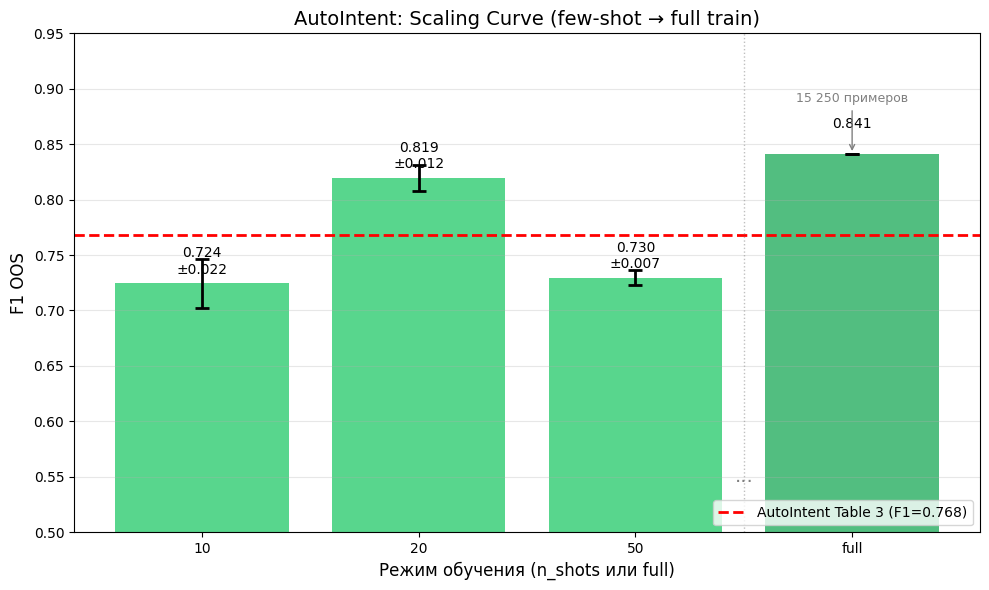

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/scaling_curve_full.png


In [10]:
# 5.2 Plot scaling curve
fig, ax = plt.subplots(figsize=(10, 6))

# Reference line: AutoIntent Table 3
REFERENCE_F1 = 0.768

# Categorical x-axis
x_labels = scaling_df["mode"].tolist()
x_pos = np.arange(len(x_labels))

# Plot bars with error bars
colors = ['#2ecc71' if mode != 'full' else '#27ae60' for mode in x_labels]
bars = ax.bar(x_pos, scaling_df["f1_oos_mean"], 
              yerr=scaling_df["f1_oos_std"], 
              capsize=5, color=colors, alpha=0.8,
              error_kw={'elinewidth': 2, 'capthick': 2})

# Add value labels on bars
for i, (bar, row) in enumerate(zip(bars, scaling_df.itertuples())):
    height = bar.get_height()
    std_str = f"±{row.f1_oos_std:.3f}" if row.f1_oos_std > 0 else ""
    ax.annotate(f'{height:.3f}\n{std_str}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Annotation for full: "15 250 примеров"
full_idx = x_labels.index("full") if "full" in x_labels else -1
if full_idx >= 0:
    ax.annotate('15 250 примеров',
                xy=(full_idx, scaling_df.iloc[full_idx]["f1_oos_mean"]),
                xytext=(0, 35), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Reference line
ax.axhline(y=REFERENCE_F1, color='red', linestyle='--', linewidth=2, 
           label=f'AutoIntent Table 3 (F1={REFERENCE_F1})')

# Visual break before "full" (add vertical line)
if full_idx > 0:
    ax.axvline(x=full_idx - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.text(full_idx - 0.5, 0.55, '...', fontsize=14, ha='center', va='center', color='gray')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Режим обучения (n_shots или full)", fontsize=12)
ax.set_ylabel("F1 OOS", fontsize=12)
ax.set_title("AutoIntent: Scaling Curve (few-shot → full train)", fontsize=14)
ax.set_ylim(0.5, 0.95)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS / "scaling_curve_full.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS / 'scaling_curve_full.png'}")

### 5.3 Выводы по scaling curve

Кривая показывает **немонотонное поведение в few-shot режиме**
(провал на 50-shot из-за overfitting threshold на val-фолдах,
подробнее в ноутбуке 03) и **восстановление при full train**.

При полных данных val-фолды становятся достаточно большими,
чтобы порог обобщался на test — F1 возвращается к росту
и **превышает референс из статьи на +7.3 п.п.**

**Ключевые точки:**
- 10-shot: F1 = 0.724 — стартовая точка
- 20-shot: F1 = 0.819 — оптимальный few-shot режим
- 50-shot: F1 = 0.730 — провал из-за overfitting
- full:    F1 = 0.841 — восстановление и превышение референса

## 6. Выводы

**Главный результат:**
- `autointent_classic-light` на full train: **F1 OOS = 0.841**
- Table 3 референс: F1 OOS = 0.768
- **Превышение на +7.3 п.п.**

**Возможные причины превышения референса:**
1. **Различие в данных:** HuggingFace `plus` (250 OOS train) vs оригинальный `data_full.json` (100 OOS train)
2. **Версия AutoIntent:** более новая версия библиотеки
3. **Embedder:** тот же `e5-large-instruct`, но возможны различия в версии модели

**Сравнение с бейзлайнами на full train:**

| Модель | F1 OOS | In-Domain Acc | Δ F1 vs AutoIntent |
|--------|--------|---------------|-------------------|
| autointent_classic-light | **0.841** | **0.940** | — |
| cosine_e5large_threshold | 0.720 | 0.908 | −12.1 п.п. |
| cosine_minilm_threshold | 0.642 | 0.875 | −19.9 п.п. |

AutoIntent даёт **+12 п.п. F1** над лучшим бейзлайном с тем же embedder'ом.
Это чистый вклад AutoML-оптимизации (scoring + decision modules).